Task 3 : Exploratory Data Analysis (EDA), Netflix Dataset

In [1]:
import pandas as pd

data_frame = pd.read_csv("netflix_titles.csv")
data_frame.head() #shows the first 5 rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
data_frame.isnull().sum() #shows missing values in a clean list

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

first I will handle the missing values in the data

In [6]:
#filling the columns with a lot of rows missing
data_frame["director"] = data_frame["director"].fillna("Not Stated")
data_frame["cast"] = data_frame["cast"].fillna("Not Stated")
data_frame["country"] = data_frame["country"].fillna("Not Stated")

#dropping the columns with a few rows missing
data_frame.dropna(subset=["date_added","rating","duration"], inplace=True)

data_frame.isnull().sum() #verifying no more null values

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [7]:
#converting date_added to datetime format
data_frame["date_added"] = pd.to_datetime(data_frame["date_added"].str.strip())

#extracting the year and month
data_frame["year_added"] = data_frame["date_added"].dt.year
data_frame["month_added"] = data_frame["date_added"].dt.month

data_frame[["date_added", "year_added", "month_added"]].head()

,date_added,year_added,month_added
0,2021-09-25,2021,9
1,2021-09-24,2021,9
2,2021-09-24,2021,9
3,2021-09-24,2021,9
4,2021-09-24,2021,9


In [8]:
#checking for duplicate entries
print("Duplicate rows: ", data_frame.duplicated().sum())

data_frame.drop_duplicates(inplace=True)

print("Dataset shape after cleaning: ",data_frame.shape)

Duplicate rows:  0
Dataset shape after cleaning:  (8790, 14)


In [9]:
data_frame.to_csv("netflix_cleaned.csv", index=False)
print("Cleaned dataset has been saved!")

Cleaned dataset has been saved!


EDA and Visualizations

In [10]:
#Summary statistics
print("Dataset Shape: ", data_frame.shape)
print("\nContent Type Distribution: ")
print(data_frame["type"].value_counts())
print("\nTop 10 producing Countries: ")
print(data_frame["country"].value_counts().head(10))
print("\nContent Rating Distribution: ")
print(data_frame["rating"].value_counts())

Dataset Shape:  (8790, 14)

Content Type Distribution: 
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Top 10 producing Countries: 
country
United States     2809
India              972
Not Stated         829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

Content Rating Distribution: 
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


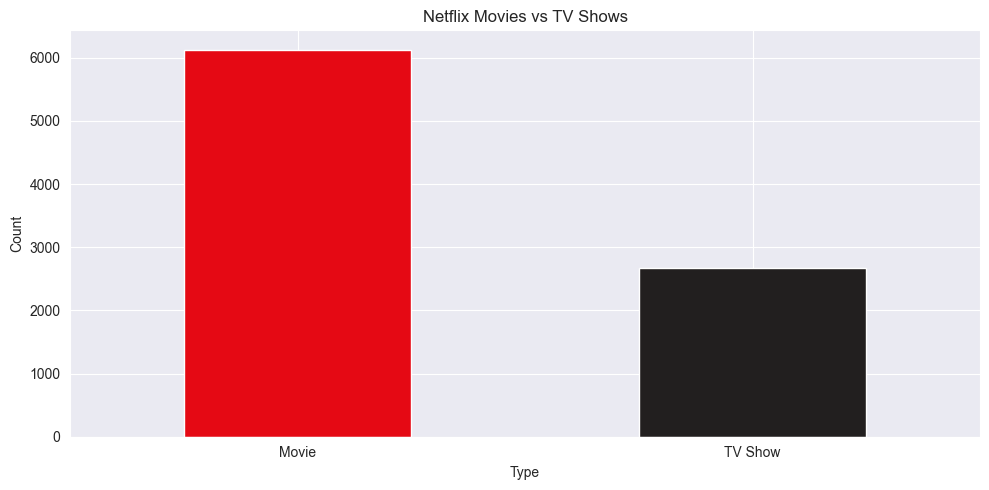

In [12]:
#ploting the summary
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10,5)

data_frame["type"].value_counts().plot(kind="bar", color=["#E50914", "#221F1F"])
plt.title("Netflix Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0) #keeps labels horizontal
plt.tight_layout() #prevents labels from getting cutoff
plt.show()

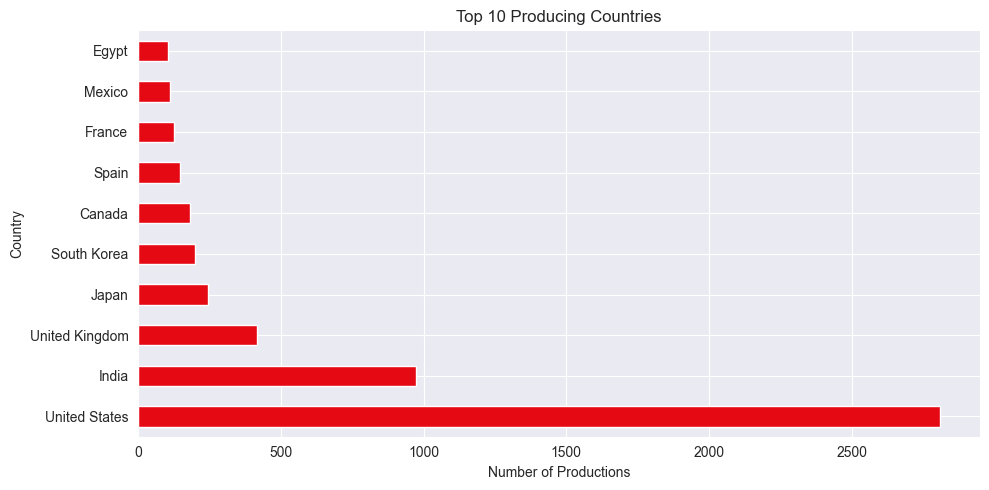

In [14]:
#plotting top 10 producing countries
country_data = data_frame[data_frame["country"] != "Not Stated"]["country"].value_counts().head(10)

country_data.plot(kind="barh", color="#E50914")
plt.title("Top 10 Producing Countries")
plt.xlabel("Number of Productions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

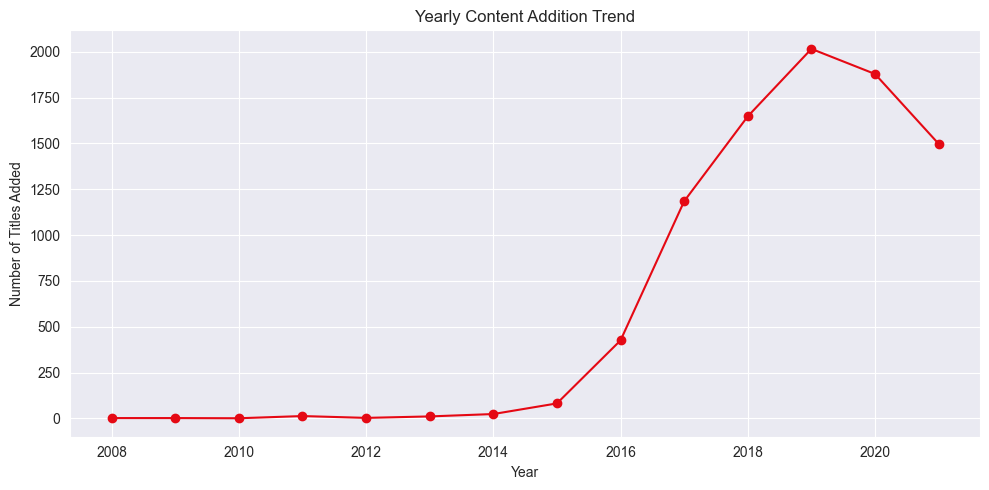

In [15]:
#Trend Identification
#Number of titles added each year
yearly_data = data_frame["year_added"].value_counts().sort_index()

yearly_data.plot(kind="line", marker="o", color="#E50914")
plt.title("Yearly Content Addition Trend")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.show()

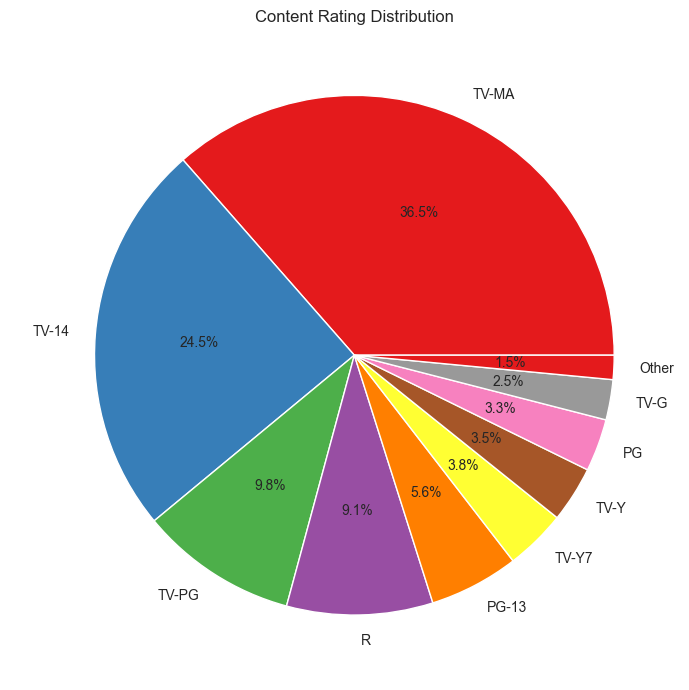

In [22]:
#Content rating distribution
rating_data = data_frame["rating"].value_counts()

#Grouping anything less than 100 titles into 'Other' 
rating_data_cleaned = rating_data[rating_data >= 100]
rating_data_cleaned["Other"] = rating_data[rating_data < 100].sum()

plt.figure(figsize=(10,7))
rating_data_cleaned.plot(kind="pie", autopct="%1.1f%%", colors=sns.color_palette("Set1"))
plt.title("Content Rating Distribution")
plt.ylabel(" ")
plt.tight_layout()
plt.show()

Correlation Analysis on Numeric Columns

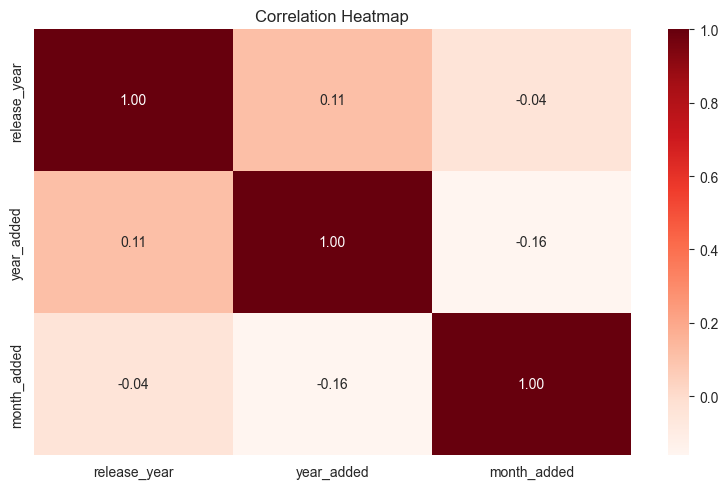

In [23]:
#correlation analysis
numeric_df = data_frame[["release_year", "year_added", "month_added"]]

correlation = numeric_df.corr()
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True, cmap="Reds", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()